# <center> ISEL - AA </center>
## <center>Semestre 2025/26 </center>
###  <center> Trabalho 1 - Pima Indians Diabetes Dataset</center>

Trabalho realizado por:
* Lucas Duarte, número <b> 50735 </b>
* Rafael Dias, número <b> 50773 </b>
* Miguel Sedas, número <b> 50801  </b>

<b> Turma 52D </b> <br></br>
<b> Docente: Gonçalo Xufre </b>

# Introdução

Os índios Pima, também conhecidos pelo nome nativo Akimel O’odham, são um povo indígena que habita principalmente o centro e sul do estado do Arizona (EUA) e regiões do noroeste do México. Historicamente, os Pima eram agricultores estabelecidos ao longo do rio Gila, de onde vem o significado do seu nome — “povo do rio”. Esta comunidade tem sido amplamente estudada por apresentar uma das maiores incidências de diabetes tipo 2 no mundo, o que levou o Instituto Nacional de Diabetes e Doenças Digestivas e Renais dos Estados Unidos a realizar um acompanhamento contínuo da sua população desde a década de 1960.

O conjunto de dados Pima Indians Diabetes Database é amplamente utilizado em estudos de classificação e aprendizagem automática, reunindo informações médicas de mulheres da etnia Pima com idades a partir dos 21 anos. Este dataset contém 768 amostras e 8 variáveis preditoras, como a concentração de glicose, pressão arterial e índice de massa corporal (IMC). A variável-alvo é binária, indicando a presença ou ausência de diabetes.

Neste trabalho, procedeu-se ao pré-processamento dos dados, incluindo a divisão em conjuntos de treino, validação e teste, seguido da normalização das variáveis. Em seguida, foram aplicados três classificadores distintos — Random Forest, SVM e K-NN — com o objetivo de comparar o seu desempenho.

A análise centrou-se no ajuste de hiperparâmetros, que controlam o comportamento e a capacidade de generalização dos modelos. As métricas de avaliação accuracy, precision, recall e F1-score foram utilizadas para comparar os classificadores, complementadas por curvas ROC para examinar a sensibilidade e especificidade de cada modelo.

Foi também explorado o impacto do ajuste dos limiares de decisão, de modo a reduzir o número de falsos negativos — aspeto particularmente importante em contextos médicos, onde a não deteção de casos positivos pode ter consequências graves. Por fim, avaliou-se o efeito da normalização no desempenho global dos classificadores.

# Modelos de Classificação

## Imports

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pickle

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


from sklearn.metrics import confusion_matrix, roc_auc_score, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler

## Carregamento dos Dados

### Abrir o pickle, ver as chaves do dataset e a descrição do mesmo

In [48]:
with open("pimaDiabetes.p", "rb") as data_file:
    D = pickle.load(data_file)

print(D.keys(), "\n")

print(D.DESCR)

dict_keys(['data', 'target', 'feature_names', 'DESCR']) 

This dataset is originally from the National
Institute of Diabetes and Digestive and Kidney Diseases.
The objective of the dataset is to diagnostically predict
whether or not a patient has diabetes, based on certain
diagnostic measurements included in the dataset.
Several constraints were placed on the selection of these
instances from a larger database. In particular, all patients
here are females at least 21 years old of Pima Indian heritage.
The dataset contains information of 768 women from a population
near Phoenix, Arizona, USA. The outcome tested was Diabetes,
268 tested positive and 500 tested negative.

For more inforamtion:
Smith, J.W., Everhart, J.E., Dickson, W.C., Knowler, W.C., & Johannes, R.S.
(1988). Using the ADAP learning algorithm to forecast the onset of diabetes mellitus.
In Proceedings of the Symposium on Computer Applications and Medical Care (pp. 261--265).
IEEE Computer Society Press.


### Separação dos dados e das suas classes

In [49]:
X = D['data']
y = D['target']

print("Caracteristicas do Dataset:\n")
for i in D ['feature_names']:
    print(i)

Caracteristicas do Dataset:

Number of times pregnant
Plasma glucose concentration at 2 Hours in an oral glucose tolerance test (GTIT)
Diastolic Blood Pressure (mm Hg)
Triceps skin fold thickness (mm)
2-Hour Serum insulin (µh/ml)
Body mass index [weight in kg/(Height in m)]
Diabetes pedigree function
Age (years)


In [50]:
# número de casos positivos e a probabilidade em relação ao total
print("Casos positivos:", np.sum(y==1), "\tProb:", np.round(np.sum(y==1)/len(y),2))
# número de casos negativos e a probabilidade em relação ao total
print("Casos negativos:", np.sum(y==0), "\tProb:", np.round(np.sum(y==0)/len(y),2))

Casos positivos: 268 	Prob: 0.35
Casos negativos: 500 	Prob: 0.65


## Modelos de Classificação

### Separação dos dados para o treino dos classificadores

Os dados foram divididos em três subconjuntos — treino, validação e teste — com o objetivo de garantir uma avaliação robusta e imparcial do desempenho dos classificadores. Optou-se por reservar 70% dos dados para as fases de treino e validação, e 30% para o teste final. Esta proporção é comum em tarefas de aprendizagem automática, pois assegura uma quantidade suficiente de dados para ajustar e otimizar os modelos, mantendo ao mesmo tempo um conjunto independente para avaliar a sua capacidade de generalização.

Dentro dos 70% destinados ao treino e validação, os dados foram novamente divididos em 50% para treino e 20% para validação. O conjunto de treino é utilizado para ajustar o classificador, testando diferentes combinações de hiperparâmetros. Já o conjunto de validação serve para avaliar o desempenho dessas combinações e identificar os hiperparâmetros ideais, sem recorrer ainda aos dados de teste. Por fim, o conjunto de teste (30% restantes) é utilizado apenas na fase final, permitindo avaliar de forma fidedigna o desempenho do modelo otimizado em dados nunca antes vistos.

In [51]:
# Proporções de cada conjunto
train_ratio = 0.50
valid_ratio = 0.20

# Tamanhos para cada conjunto
train_size = int(X.shape[0] * train_ratio)
valid_size = int(X.shape[0] * valid_ratio)

# Dividir X e y entre treino, validação e teste
X_train = X[:train_size]
y_train = y[:train_size]

X_valid = X[train_size:train_size + valid_size]
y_valid = y[train_size:train_size + valid_size]

X_test = X[train_size + valid_size:]
y_test = y[train_size + valid_size:]

# Print dos tamanhos de cada conjunto
print("Conjunto de treino:", X_train.shape, y_train.shape)
print("Conjunto de validação:", X_valid.shape, y_valid.shape)
print("Conjunto de teste:", X_test.shape, y_test.shape)

Conjunto de treino: (384, 8) (384,)
Conjunto de validação: (153, 8) (153,)
Conjunto de teste: (231, 8) (231,)


### Escolha dos classificadores

O grupo optou por utilizar os seguintes classificadores:

Random Forest Classifier – Este modelo baseia-se num conjunto de árvores de decisão e é particularmente eficaz em situações onde existem relações não lineares entre as variáveis. No caso do dataset dos índios Pima, é provável que existam interações complexas entre atributos como níveis de glicose, pressão arterial e idade, que o Random Forest consegue capturar de forma mais eficiente do que modelos lineares.

Support Vector Machine (SVM) – Como a fronteira entre as classes (pacientes com e sem diabetes) pode não ser linear, o SVM, especialmente com a utilização de kernels, permite transformar os dados para um espaço de maior dimensão, onde a separação entre as classes se torna mais clara e precisa.

K-Nearest Neighbours (K-NN) - O K-NN é um classificador que decide a classe de um novo exemplo olhando para os k exemplos mais parecidos com ele no conjunto de dados. Ou seja, se a maioria dos vizinhos próximos tiver diabetes, o modelo prevê que o novo paciente também terá.

#### Random Forest Classifier

O Random Forest é um dos algoritmos mais utilizados em problemas de classificação e regressão, devido à sua robustez, versatilidade e bom desempenho em diferentes tipos de dados. No contexto deste trabalho, foi escolhido por ser particularmente eficaz na deteção de relações complexas e não lineares entre as variáveis.

Este classificador baseia-se na construção de múltiplas árvores de decisão, onde cada árvore é treinada com um subconjunto aleatório dos dados de treino. Durante o processo de construção, em cada nó, o algoritmo seleciona aleatoriamente um conjunto limitado de atributos para determinar a melhor divisão. Cada árvore produz a sua própria previsão, e o resultado final do modelo é obtido por votação maioritária entre todas as árvores.

A introdução de aleatoriedade, tanto na seleção de amostras como na escolha de atributos, é o que confere ao Random Forest uma forte resistência ao overfitting, um problema comum em árvores de decisão isoladas. Ao combinar as previsões de várias árvores independentes, o modelo torna-se mais estável, preciso e menos sensível a ruídos nos dados.

Para otimizar o desempenho do classificador, foi desenvolvido um código que testa diferentes combinações de hiperparâmetros principais: o número de árvores no modelo (n_estimators), a profundidade máxima permitida para cada árvore (max_depth) e o número mínimo de amostras necessárias para dividir um nó (min_samples_split). Para cada combinação, o classificador é treinado com o conjunto de treino e avaliado com o conjunto de validação. No final, a combinação de hiperparâmetros que resulta na maior taxa de acerto é selecionada e apresentada juntamente com a sua precisão obtida.

In [52]:
# Random Forest Classifier

def aval_rf(n_estimators, max_depth, min_samples_split, 
            X_train, y_train, X_valid, y_valid):
    """
    Args:
        n_estimators: Número de árvores na floresta
        max_depth: Profundidade máxima permitida para cada árvore
        min_samples_split: Número mínimo de amostras necessário para dividir um nó
        X_train: Conjunto de dados de treino
        y_train: Labels do conjunto de treino
        X_valid: Conjunto de dados de validação
        y_valid: Labels do conjunto de validação

    Returns:
        accuracy: Probabilidade de acertos do classificador
    """
    # Inicializar o classificador com os parâmetros da função
    rf = RandomForestClassifier(n_estimators=n_estimators,
                                max_depth=max_depth,
                                min_samples_split=min_samples_split,
                                random_state=42)
    
    # Treinar o modelo com o conjunto de dados de treino
    rf.fit(X_train, y_train)
    # Calcular a probabilidade de acertos do modelo com o conjunto de validação
    accuracy = rf.score(X_valid, y_valid)
    return accuracy

# Definir os valores dos hiperparâmetros
n_estimators_values = [50, 100, 200]  
max_depth_values = [None, 10, 20, 30]  
min_samples_split_values = [2, 5, 10]

# Variáveis para guardar os melhores parâmetros e a melhor probabilidade de acertos
best_accuracy = 0
best_params = {}

# Percorre todas as combinações dos valores de hiperparâmetros
for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        for min_samples_split in min_samples_split_values:
            # Avaliar o modelo com a combinação atual de hiperparâmetros
            accuracy = aval_rf(n_estimators, max_depth, min_samples_split, 
                               X_train, y_train, X_valid, y_valid)
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {
                    'n_estimators': n_estimators,
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split
                }

# Print dos resultados
print("\nMelhores parâmetros encontrados:")
print(best_params)
print(f"Precisão com os melhores parâmetros: {best_accuracy:.4f}")


Melhores parâmetros encontrados:
{'n_estimators': 200, 'max_depth': None, 'min_samples_split': 10}
Precisão com os melhores parâmetros: 0.8235


#### Support Vector Machine (SVM)

O Support Vector Machine (SVM) é um classificador bastante utilizado em problemas de classificação supervisionada, devido à sua capacidade de encontrar fronteiras de decisão ideais mesmo em conjuntos de dados complexos. O seu princípio baseia-se na identificação de um hiperplano ótimo que separa as classes, maximizando a margem entre os pontos mais próximos de cada classe — os chamados vetores de suporte.

Uma das grandes vantagens do SVM é o uso de funções kernel, que permitem transformar os dados originais para espaços de maior dimensão, possibilitando a separação de classes não linearmente separáveis. Entre os kernels mais comuns encontram-se o linear, o RBF (Radial Basis Function) e o sigmoid. O modelo é regulado por dois hiperparâmetros principais:

- C, que controla o equilíbrio entre uma margem mais ampla e a penalização de erros de classificação;

- gamma, que define o grau de influência que cada ponto de treino exerce na definição da fronteira de decisão.

O processo de ajuste destes parâmetros é essencial para alcançar um equilíbrio entre precisão e generalização, evitando tanto o overfitting como o underfitting.
Para determinar os melhores valores de kernel, C e gamma, foi desenvolvido um código que testa várias combinações desses hiperparâmetros. O modelo é treinado com o conjunto de treino e avaliado com o conjunto de validação, sendo guardada e exibida no final a configuração que apresentou a maior precisão de classificação.

In [53]:
# Classificador SVM

def aval_svm(kernel, C, gamma, X_train, y_train, X_valid, y_valid):
    """aval_svm

    Args:
        kernel: especifica o tipo de função de kernel a ser utilizada pelo SVM (por exemplo, 'linear', 'rbf', etc.)
        C: parâmetro de regularização que controla o grau de penalização de erros de classificação
        gamma: define a influência de cada ponto de dados (em kernels 'rbf', 'sigmoid' e 'poly')
        X_train: conjunto de dados de treino
        y_train: rótulos do conjunto de treino
        X_valid: conjunto de dados de validação
        y_valid: rótulos do conjunto de validação

    Returns:
        accuracy: precisão do modelo no conjunto de validação
    """
    
    # Inicializar o modelo SVM com os hiperparâmetros passados
    svm = SVC(kernel=kernel,
              C=C,
              gamma=gamma,
              random_state=42)
    
    # Treinar o modelo SVM com o conjunto de treino
    svm.fit(X_train, y_train)
    
    # Ver a probabilidade de acertos do modelo
    accuracy = svm.score(X_valid, y_valid)
    return accuracy

# Valores dos hiperparâmetros a ser testados
# Testou-se o kernel "poly", mas demorava muito tempo e encravava o PC
kernels = ['linear', 'rbf', 'sigmoid']   
C_values = [0.1, 1, 10] 
gamma_values = ['scale', 'auto'] 

# Variáveis para guardar a melhor probabilidade de acertos e os melhores parâmetros encontrados
best_accuracy = 0
best_params = {}

# Percorrer todas as combinações possíveis dos hiperparâmetros
for kernel in kernels:
    for C in C_values:
        for gamma in gamma_values:
            # Avaliar o modelo SVM com a combinação atual de hiperparâmetros
            accuracy = aval_svm(kernel, C, gamma, X_train, y_train, X_valid, y_valid)
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {
                    'kernel': kernel,
                    'C': C,
                    'gamma': gamma
                }

# Print dos resultados
print("\nMelhores parâmetros encontrados:")
print(best_params)
print(f"Precisão com os melhores parâmetros: {best_accuracy:.4f}")


Melhores parâmetros encontrados:
{'kernel': 'linear', 'C': 1, 'gamma': 'scale'}
Precisão com os melhores parâmetros: 0.8235


#### K-NN

O classificador K-Nearest Neighbors (K-NN) é amplamente utilizado em problemas de classificação, destacando-se pela sua simplicidade e capacidade de adaptação a diferentes distribuições de dados. Baseia-se num modelo não paramétrico que atribui a classe de uma amostra com base nas classes dos seus vizinhos mais próximos, recorrendo a uma métrica de distância (como a distância Euclidiana) para determinar quais os vizinhos mais próximos. O seu objetivo é classificar cada amostra considerando a predominância das classes no seu entorno.

O K-NN apresenta várias vantagens, como a facilidade de implementação, a ausência de suposições sobre a distribuição dos dados e a capacidade de capturar relações complexas quando os dados não são linearmente separáveis. O modelo é controlado por alguns hiperparâmetros essenciais, nomeadamente n_neighbors, que define o número de vizinhos a considerar para a classificação; weights, que determina se todos os vizinhos têm o mesmo peso ou se os vizinhos mais próximos têm maior influência; e metric, que especifica a métrica de distância a utilizar para calcular a proximidade entre amostras.

Para encontrar a melhor configuração do classificador, foi desenvolvido um código que testa diferentes combinações dos hiperparâmetros n_neighbors, weights e metric. O modelo é treinado com o conjunto de treino e avaliado com o conjunto de validação, registando a precisão obtida em cada combinação. A melhor combinação de parâmetros, correspondente à maior taxa de acerto, é selecionada e guardada, resultando num modelo mais adequado aos dados e ao objetivo de classificação.

In [54]:
# Classificador K-Nearest Neighbors

def aval_knn(n_neighbors, weights, metric, X_train, y_train, X_valid, y_valid):
    """aval_knn

    Args:
        n_neighbors: Número de vizinhos a considerar para a classificação.
        weights: Peso dado aos vizinhos ('uniform' ou 'distance').
        metric: Métrica de distância a utilizar ('euclidean', 'manhattan', etc.).
        X_train: Conjunto de dados de treino.
        y_train: Rótulos do conjunto de treino.
        X_valid: Conjunto de dados de validação.
        y_valid: Rótulos do conjunto de validação.

    Returns:
        accuracy: Probabilidade de acertos do modelo avaliado no conjunto de validação.
    """
    # Criar o modelo K-NN com os hiperparâmetros especificados
    knn = KNeighborsClassifier(n_neighbors=n_neighbors,
                               weights=weights,
                               metric=metric)
    
    # Treinar o classificador com o conjunto de treino
    knn.fit(X_train, y_train)
    
    # Calcular a probabilidade de acertos no conjunto de validação
    accuracy = knn.score(X_valid, y_valid)
    return accuracy

# Definir os valores dos hiperparâmetros a testar
n_neighbors_values = [3, 5, 7, 9]
weights_values = ['uniform', 'distance']
metric_values = ['euclidean', 'manhattan']

# Variáveis para guardar os melhores parâmetros e a melhor precisão
best_accuracy = 0
best_params = {}

# Testar todas as combinações de valores para os hiperparâmetros
for n in n_neighbors_values:
    for w in weights_values:
        for m in metric_values:
            # Avaliar o modelo com a combinação atual de hiperparâmetros
            accuracy = aval_knn(n, w, m, X_train, y_train, X_valid, y_valid)
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {
                    'n_neighbors': n,
                    'weights': w,
                    'metric': m
                }

# Resultados
print("\nMelhores parâmetros encontrados:")
print(best_params)
print(f"Precisão com os melhores parâmetros: {best_accuracy:.4f}")


Melhores parâmetros encontrados:
{'n_neighbors': 9, 'weights': 'distance', 'metric': 'euclidean'}
Precisão com os melhores parâmetros: 0.7908


## Métricas

Os melhores hiperparâmetros para cada classificador foram determinados na fase anterior e serão agora utilizados para proceder à análise das métricas de desempenho de cada modelo.

Para o Random Forest, a configuração ideal foi obtida com n_estimators=200, max_depth=None (sem limite de profundidade nas árvores) e min_samples_split=10, o que significa que uma divisão de nó apenas ocorre quando existem pelo menos 10 amostras nesse nó.

No caso do SVM, a melhor combinação encontrada corresponde a um kernel linear, com C=1 e gamma='scale', garantindo um bom equilíbrio entre precisão e generalização.

Por fim, para o classificador K-Nearest Neighbors (K-NN), os melhores parâmetros foram n_neighbors=9, weights='distance' e metric='euclidean', permitindo classificar cada amostra com base nos 9 vizinhos mais próximos, dando maior peso aos mais próximos e utilizando a distância Euclidiana.

Com base nestas configurações, procedeu-se à análise das métricas de desempenho dos classificadores, de forma a comparar a eficácia de cada um nas previsões realizadas.

In [55]:
# {'n_estimators': 200, 'max_depth': None, 'min_samples_split': 10}
random_forest = RandomForestClassifier(n_estimators=200, max_depth=None,min_samples_split=10, random_state=42)

#{'kernel': 'linear', 'C': 1, 'gamma': 'scale'}
svm = SVC(kernel='linear', C=1, gamma='scale', probability=True)

# {'n_neighbors': 9, 'weights': 'distance', 'metric': 'euclidean'}
knn = KNeighborsClassifier(n_neighbors=9, weights='distance', metric='euclidean')

Nesta etapa, o conjunto de treino foi combinado com o conjunto de validação, uma vez que essa divisão era apenas necessária durante a fase de ajuste dos hiperparâmetros. Como esses parâmetros já foram otimizados, a junção dos conjuntos permite aumentar a quantidade de dados disponíveis para o treino final, tornando o modelo mais robusto. Com os classificadores treinados com os melhores hiperparâmetros, procedeu-se à análise dos resultados através do cálculo da matriz de confusão e das principais métricas de desempenho — probabilidade total de acertos (accuracy), precisão (precision), recall (sensibilidade) e F-score — de forma a avaliar a eficácia de cada classificador.

In [56]:
# Combina os dados de treino (X_train, y_train) e validação (X_valid, y_valid) num único conjunto para reavaliar o modelo 
# com mais dados durante o treino.
X_combined = np.concatenate((X_train, X_valid), axis=0)
y_combined = np.concatenate((y_train, y_valid), axis=0)

# avaliar o desempenho de um classificador em conjunto de teste
def aval_clf(clf, X_train, y_train, X_test, y_test):
    # nome da classe do modelo para identificar o classificador avaliado
    print(f"Avaliação - {clf.__class__.__name__} ")
    
    # Treina o classificador com os dados de treino
    clf.fit(X_train, y_train)
    
    # previsões sobre o conjunto de teste.
    y_pred = np.array(clf.predict(X_test))
    
    # Calcular a matriz de confusão 
    conf_matrix = confusion_matrix(y_test, y_pred)

    print("Matriz de Confusão:")
    print(conf_matrix)

    TN, FP, FN, TP = conf_matrix.ravel()

    # Percentagem total de classificações corretas
    accuracy = (TP + TN) / (TP + FP + TN + FN)
    # Percentagem das previsões positivas que são realmente corretas
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    # Percentagem dos casos positivos corretamente identificados
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    # Média entre precision e recall para equilibrar os dois
    f_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    # Print dos resultados das métricas calculadas.
    print()
    print("Probabilidade total de acertos:", np.round(accuracy, 4))
    print("Precision:", np.round(precision, 4))
    print("Recall:", np.round(recall, 4))
    print("F-Score:", np.round(f_score, 4))
    print()

### Métricas do Random Forest

In [57]:
aval_clf(random_forest, X_combined, y_combined, X_test, y_test)

Avaliação - RandomForestClassifier 
Matriz de Confusão:
[[138  14]
 [ 33  46]]

Probabilidade total de acertos: 0.7965
Precision: 0.7667
Recall: 0.5823
F-Score: 0.6619



Com base nos resultados obtidos para o classificador Random Forest no conjunto de teste, observa-se um bom desempenho geral, embora com alguma limitação na sensibilidade. A matriz de confusão indica 138 verdadeiros negativos, 46 verdadeiros positivos, 33 falsos negativos e 14 falsos positivos. A probabilidade total de acertos (79,65%) mostra uma boa capacidade de previsão, mas o recall (58,23%) revela dificuldade em identificar todos os casos positivos. Já a precisão (76,67%) demonstra um bom controlo de falsos positivos, e o F-Score (66,19%) evidencia um equilíbrio razoável entre precisão e recall.

### Métricas do SVM

In [58]:
aval_clf(svm, X_combined, y_combined, X_test, y_test)

Avaliação - SVC 
Matriz de Confusão:
[[137  15]
 [ 37  42]]

Probabilidade total de acertos: 0.7749
Precision: 0.7368
Recall: 0.5316
F-Score: 0.6176



O classificador SVM apresenta um desempenho geral satisfatório, mas com dificuldades na identificação de casos positivos. A matriz de confusão evidencia 137 verdadeiros negativos, 42 verdadeiros positivos, 37 falsos negativos e 15 falsos positivos. A probabilidade total de acertos (77,49%) mostra um bom desempenho global, e a precisão (73,68%) indica boa capacidade de evitar falsos positivos. No entanto, o recall (53,16%) é baixo, revelando falhas na deteção de vários casos de diabetes. O F-Score (61,76%) confirma um equilíbrio razoável entre precisão e recall.

### Métricas do KNN

In [59]:
aval_clf(knn, X_combined, y_combined, X_test, y_test)

Avaliação - KNeighborsClassifier 
Matriz de Confusão:
[[129  23]
 [ 33  46]]

Probabilidade total de acertos: 0.7576
Precision: 0.6667
Recall: 0.5823
F-Score: 0.6216



O classificador K-Nearest Neighbors (K-NN) apresenta um desempenho global satisfatório no conjunto de teste, embora com algumas limitações. A matriz de confusão indica 129 verdadeiros negativos e 46 verdadeiros positivos, bem como 33 falsos negativos e 23 falsos positivos. A probabilidade total de acertos (75,76%) mostra que o modelo acerta na maior parte das previsões, e a precisão (66,67%) evidencia uma capacidade razoável de evitar falsos positivos. No entanto, o recall (58,23%) revela alguma dificuldade em identificar todos os casos positivos, originando falsos negativos. O F-Score (62,16%) apresenta um equilíbrio moderado entre precisão e recall, refletindo o desempenho global do modelo.

## Calibração

Em problemas como a previsão de diabetes, é essencial reduzir ao máximo os falsos negativos, ou seja, os casos em que o modelo falha ao identificar pacientes que realmente têm a doença. Um falso negativo pode atrasar o diagnóstico e o início do tratamento, aumentando o risco de complicações graves. A análise inicial dos classificadores mostrou que o número de falsos negativos era demasiado elevado para um cenário clínico, tornando necessária uma otimização adicional.

Para corrigir este problema, tornou-se necessário ajustar o limiar de decisão (threshold) dos modelos. O limiar padrão de 0.5 classifica uma amostra como positiva apenas quando a probabilidade prevista é igual ou superior a 50%. No entanto, em contextos médicos, é vantajoso reduzir este limiar, tornando o modelo mais sensível e capaz de identificar mais casos positivos — mesmo que isso aumente o número de falsos positivos. Este aumento é aceitável, pois é preferível que um paciente seja erroneamente sinalizado como tendo risco de diabetes (e confirmado depois que não tem) do que não identificar alguém que realmente tem a doença.

O ajuste do limiar foi feito com base na curva ROC, que permite analisar o desempenho dos modelos para diferentes valores de threshold e assim identificar o ponto que proporciona maior sensibilidade. O objetivo foi encontrar um limiar que atingisse uma taxa de verdadeiros positivos (TPR) de pelo menos 90%, reduzindo significativamente os falsos negativos sem comprometer excessivamente outras métricas.

Para implementar esta abordagem, desenvolveu-se código que ajusta dinamicamente o limiar de decisão com base na curva ROC e reaplica o modelo com o novo valor. Após determinar os limiares adequados para cada classificador, estes foram novamente avaliados, permitindo obter modelos mais sensíveis e alinhados com as necessidades específicas do problema.

Desta forma, os classificadores ficam melhor adaptados ao contexto clínico, priorizando a identificação correta de pacientes com diabetes e reduzindo o risco associado a diagnósticos tardios.

In [60]:
# avaliação as métricas de um classificador com ajuste de threshold
def aval_metrics_clf(clf, X_train, y_train, X_test, y_test, threshold=0.5):
    
    print(f"Avaliação - {clf.__class__.__name__} com threshold = {threshold}")
    # Lista para guardar as métricas calculadas
    metrics = []  

    # Treina o modelo com os dados de treino
    clf.fit(X_train, y_train)
    
    # Obter as probabilidades previstas para a classe positiva (classe 1)
    y_pred_proba = clf.predict_proba(X_test)[:, 1]

    # Ajustar as previsões com base no threshold escolhido
    y_pred = (y_pred_proba >= threshold).astype(int)
    
    # matriz de confusão
    conf_matrix = confusion_matrix(y_test, y_pred)
    print("Matriz de Confusão:")
    print(conf_matrix)
    
    TN, FP, FN, TP = conf_matrix.ravel()
    
    # Cálculo das métricas de avaliação
    accuracy = (TP + TN) / (TP + FP + TN + FN)  
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0  
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0  
    f_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0  

    # Print das métricas calculadas
    print("\nAccuracy:", np.round(accuracy, 4))
    print("Precision:", np.round(precision, 4))
    print("Recall:", np.round(recall, 4))
    print("F-Score:", np.round(f_score, 4))

    # Guardar as métricas e o nome do classificador numa lista
    metrics.append(clf.__class__.__name__)  
    metrics.append(accuracy)  
    metrics.append(precision)  
    metrics.append(recall)  
    metrics.append(f_score)  

    return y_pred_proba, conf_matrix.ravel(), metrics
    

# ajuste do melhor threshold para cada classificador
def descobrir_limirar_clfs(clfs):
    # Lista para guardar os limiares ajustados para cada classificador
    limiares_escolhidos = []  

    for clf in clfs:
        # Calcular a curva ROC (FPR, TPR e thresholds) com base nas probabilidades previstas
        y_pred_proba = clf.predict_proba(X_test)[:, 1]
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
        
        # Definir o TPR (taxa de verdadeiros positivos) desejado
        tpr_threshold = 0.9
        # Encontrar o índice do limiar que atinge ou supera o TPR desejado
        index = np.argmax(tpr >= tpr_threshold)
        # obtém o threshold correspondente
        chosen_threshold = thresholds[index]
        limiares_escolhidos.append(chosen_threshold)
        
        # Print do limiar ajustado para o classificador
        print(f"Limiar ajustado para {clf.__class__.__name__}: {np.round(chosen_threshold, 3)}")
    
    # Retorna os limiares ajustados para cada classificador
    return limiares_escolhidos

# Lista dos classificadores usados
classificadores = [random_forest, svm, knn]
# Ajustar os thresholds para cada classificador com base na curva ROC
thresholds = descobrir_limirar_clfs(classificadores)

Limiar ajustado para RandomForestClassifier: 0.258
Limiar ajustado para SVC: 0.255
Limiar ajustado para KNeighborsClassifier: 0.286


### Métricas Recalculadas do Random Forest

In [61]:
avalM_RF = aval_metrics_clf(random_forest, X_combined, y_combined, X_test, y_test, thresholds[0])

Avaliação - RandomForestClassifier com threshold = 0.25818617697661805
Matriz de Confusão:
[[95 57]
 [ 7 72]]

Accuracy: 0.7229
Precision: 0.5581
Recall: 0.9114
F-Score: 0.6923


Após ajustar o limiar de decisão para 0.258, o desempenho do Random Forest Classifier apresentou mudanças relevantes. A precisão diminuiu de 0.7667 para 0.5581, refletindo um aumento no número de falsos positivos. No entanto, o recall aumentou substancialmente de 0.5823 para 0.9114, evidenciando uma melhoria clara na capacidade do modelo em identificar casos positivos. Embora a accuracy tenha descido de 0.7965 para 0.7229, o F-score registou um ligeiro aumento, demonstrando que o modelo se tornou mais eficaz na deteção de diabetes, reduzindo de forma significativa os falsos negativos. Estes resultados mostram que o ajuste do limiar cumpriu o objetivo de priorizar a identificação de pacientes com diabetes, mesmo ao custo de um maior número de falsos positivos.

### Métricas Recalculadas do SVM

In [62]:
avalM_SVM = aval_metrics_clf(svm, X_combined, y_combined, X_test, y_test, thresholds[1])

Avaliação - SVC com threshold = 0.25521969090409974
Matriz de Confusão:
[[101  51]
 [  7  72]]

Accuracy: 0.7489
Precision: 0.5854
Recall: 0.9114
F-Score: 0.7129


Após ajustar o limiar de decisão para 0.261, o desempenho do SVC também sofreu alterações significativas. A precisão diminuiu de 0.7368 para 0.5659, refletindo um aumento dos falsos positivos, enquanto o recall subiu de forma expressiva de 0.5316 para 0.9241, demonstrando uma melhoria clara na capacidade do modelo em identificar casos positivos. A accuracy passou de 0.7749 para 0.7316, mostrando uma ligeira redução no desempenho global, mas o F-score aumentou de 0.6176 para 0.7019, revelando um melhor equilíbrio entre precisão e recall após o ajuste do limiar. Estes valores podem variar a cada execução.

### Métricas Recalculadas do KNN

In [63]:
avalM_KNN = aval_metrics_clf(knn, X_combined, y_combined, X_test, y_test, thresholds[2])

Avaliação - KNeighborsClassifier com threshold = 0.28577577527324804
Matriz de Confusão:
[[89 63]
 [ 6 73]]

Accuracy: 0.7013
Precision: 0.5368
Recall: 0.9241
F-Score: 0.6791


Após ajustar o limiar de decisão para 0.2858, o desempenho do KNeighborsClassifier apresentou alterações importantes. A precisão diminuiu de 0.6667 para 0.5368, refletindo um aumento nos falsos positivos. Por outro lado, o recall aumentou de forma expressiva, passando de 0.5823 para 0.9241, o que evidencia uma melhoria clara na capacidade do modelo de identificar corretamente os casos positivos. A probabilidade total de acertos reduziu-se de 0.7576 para 0.7013, mas o F-score subiu de 0.6216 para 0.6791, demonstrando um equilíbrio mais favorável entre precisão e recall após o ajuste do limiar.

O ajuste do limiar de decisão nos diferentes modelos resultou numa redução significativa dos falsos negativos, aumentando de forma clara a sensibilidade na identificação de pacientes com diabetes. Embora a precisão tenha sofrido uma ligeira diminuição, o aumento do recall e do F-score demonstra uma classificação mais equilibrada e orientada para a deteção dos casos positivos. Assim, foi possível melhorar a capacidade dos modelos em identificar corretamente pacientes com diabetes, tornando a previsão da doença mais eficaz e contribuindo para uma intervenção preventiva mais adequada.

## Curva ROC Comparativa dos 3 Classificadores

A Curva ROC (Receiver Operating Characteristic) é uma ferramenta fundamental para avaliar o desempenho de classificadores binários, mostrando a relação entre a Taxa de Verdadeiros Positivos (TPR) e a Taxa de Falsos Positivos (FPR) para diferentes valores de limiar. No gráfico, o eixo X representa a FPR, enquanto o eixo Y corresponde à TPR. A Área Sob a Curva (AUC) resume o desempenho global: valores próximos de 1 indicam excelente capacidade de separação entre as classes, enquanto valores próximos de 0.5 sugerem desempenho semelhante ao acaso.

Os pontos vermelhos no gráfico assinalam o desempenho real de cada modelo após o ajuste do limiar, representando os valores de FPR e TPR obtidos a partir das respetivas matrizes de confusão. Estes pontos permitem visualizar como cada classificador equilibra falsos positivos e verdadeiros positivos. Quanto mais próximo um ponto estiver do canto superior esquerdo, melhor é o desempenho, refletindo alta sensibilidade e baixa taxa de erros. Assim, a Curva ROC possibilita comparar os modelos — Random Forest, SVM e KNN — e avaliar de forma clara o impacto do ajuste do limiar nos seus resultados.

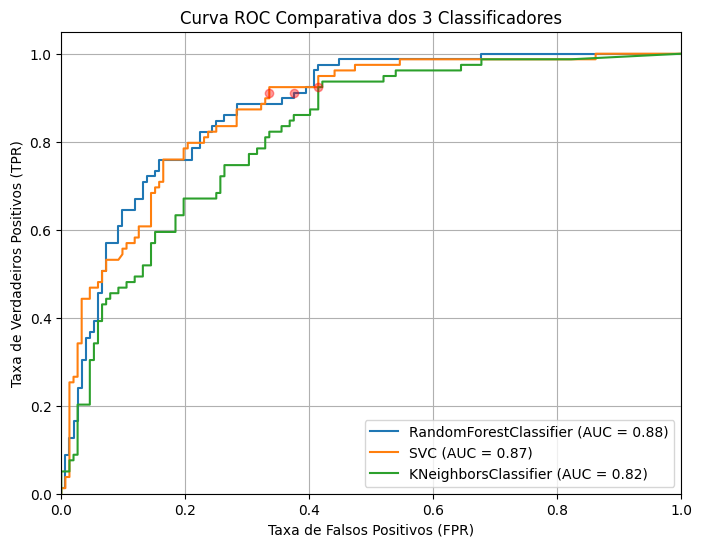

In [64]:
def roc_curve_grafDraw(clf, y_pred_proba, conf_matrix):
    # tamanho da figura para o gráfico
    plt.figure(figsize=(8, 6))
    
    # Percorrer os valores utilizados para construir a curva
    for clf, y_pred_proba, conf_matrix in zip(clfs, y_pred_probas, conf_matrix):
        # Calcular os valores para a curva ROC
        fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
        
        # Calcular a área sob a curva ROC (AUC - Area Under Curve)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        # Plot da curva ROC para o classificador atual
        plt.plot(fpr, tpr, label=f"{clf.__class__.__name__} (AUC = {roc_auc:.2f})")
        
        TN, FP, FN, TP = conf_matrix.ravel()
        
        # Adiciona um ponto no gráfico da posição da métrica baseada em TP e FP
        # FP rate: FP / (TN + FP)
        # TP rate: TP / (TP + FN)
        plt.plot(FP / (TN + FP), TP / (TP + FN), 'or', alpha=0.4) 
    
    # gráfico
    plt.grid(True)
    plt.xlim([0.0, 1.0])  # Limites do eixo X
    plt.ylim([0.0, 1.05])  # Limites do eixo Y
    plt.xlabel("Taxa de Falsos Positivos (FPR)")
    plt.ylabel("Taxa de Verdadeiros Positivos (TPR)")
    plt.title("Curva ROC Comparativa dos 3 Classificadores") 
    plt.legend(loc="lower right")
    plt.show()  

# Lista dos classificadores usados
clfs = [random_forest, svm, knn]

# Lista das probabilidades preditas para cada classificador 
y_pred_probas = [avalM_RF[0], avalM_SVM[0], avalM_KNN[0]]

# Lista das matrizes de confusão associadas a cada classificador
conf_matrix = [avalM_RF[1], avalM_SVM[1], avalM_KNN[1]]

# desenhar a curva
roc_curve_grafDraw(clfs, y_pred_probas, conf_matrix)

A análise das curvas ROC mostra que o RandomForestClassifier (linha azul) apresenta o melhor desempenho global entre os três modelos, exibindo uma AUC de 0.88. A sua curva situa-se consistentemente acima das restantes ao longo de grande parte do gráfico, indicando uma maior capacidade de distinguir entre casos positivos e negativos.

O SVC (linha laranja) surge logo a seguir, com uma AUC de 0.87, demonstrando um desempenho bastante competitivo e muito próximo do Random Forest. A sua curva acompanha de forma consistente a do modelo líder, revelando boa sensibilidade e especificidade ao longo dos diferentes limiares.

Já o KNeighborsClassifier (linha verde) apresenta um desempenho inferior relativamente aos outros dois modelos, com uma AUC de 0.82. A curva encontra-se mais afastada do canto superior esquerdo do gráfico, refletindo uma menor capacidade discriminativa.

Os pontos vermelhos representados na curva destacam limiares específicos avaliados durante a análise. Estes pontos encontram-se em regiões de elevada taxa de verdadeiros positivos (TPR), sugerindo que os limiares testados estavam orientados para maximizar a sensibilidade, ainda que à custa de um aumento da taxa de falsos positivos (FPR).

No geral, os três modelos apresentam desempenhos sólidos, todos com AUCs acima de 0.80. No entanto, o Random Forest destaca-se como o classificador mais eficaz neste conjunto de dados, seguido de perto pelo SVC, enquanto o KNN mostra um comportamento mais modesto mas ainda satisfatório.

# Pré-processamento dos dados

## Normalizar os dados

Após a preparação e análise preliminar dos dados, procedeu-se à normalização. Este processo consiste em transformar as variáveis para que todas fiquem na mesma escala, com média igual a 0 e desvio padrão igual a 1.

In [65]:
# inicialização do objeto StandardScaler para normalizar os dados
scaler = StandardScaler()

# ajustar o scaler aos dados de treino e transforma esses dados para terem a média 0 e desvio padrão 1.
X_train = scaler.fit_transform(X_train)

# transformação do conjunto de validação, que é feito com o scaler já ajustado aos dados de treino, 
X_valid = scaler.transform(X_valid)

# Transformação do conjunto de teste
X_test = scaler.transform(X_test)

# verificar os tamanhos dos conjuntos após a normalização
print("Conjunto de treino:", X_train.shape, y_train.shape)
print("Conjunto de validação:", X_valid.shape, y_valid.shape)
print("Conjunto de teste:", X_test.shape, y_test.shape)

# matriz de covariância do conjunto de treino normalizado.
# rowvar=False garante que cada coluna seja tratada como uma variável (features)
cov_matrix = np.round(np.cov(X_train, rowvar=False), 2)

print("\nMatriz de Covariância:\n", cov_matrix)

# guardar a diagonal da matriz de covariância
diagonal = np.diag(cov_matrix)
print("\nDiagonal da Matriz de Covariância (variância):\n", diagonal)

Conjunto de treino: (384, 8) (384,)
Conjunto de validação: (153, 8) (153,)
Conjunto de teste: (231, 8) (231,)

Matriz de Covariância:
 [[ 1.    0.19  0.1  -0.06 -0.02  0.07 -0.05  0.56]
 [ 0.19  1.    0.1  -0.01  0.37  0.21  0.18  0.32]
 [ 0.1   0.1   1.    0.14  0.08  0.22 -0.03  0.24]
 [-0.06 -0.01  0.14  1.    0.46  0.34  0.17 -0.15]
 [-0.02  0.37  0.08  0.46  1.    0.19  0.23  0.03]
 [ 0.07  0.21  0.22  0.34  0.19  1.    0.09  0.09]
 [-0.05  0.18 -0.03  0.17  0.23  0.09  1.    0.04]
 [ 0.56  0.32  0.24 -0.15  0.03  0.09  0.04  1.  ]]

Diagonal da Matriz de Covariância (variância):
 [1. 1. 1. 1. 1. 1. 1. 1.]


Após a normalização, os conjuntos de treino, validação e teste passaram a ter o mesmo formato, com 8 características cada, e as variáveis apresentaram média zero e desvio padrão igual a um. A matriz de covariância evidencia que as variáveis possuem correlações baixas fora da diagonal, enquanto as variâncias na diagonal são todas iguais a 1, garantindo que todas as características tenham a mesma importância no treino e evitando que o modelo seja influenciado por escalas diferentes.

## Testes com dados normalizados

### Hiperparametros do RandomForest com os Dados Normalizados

In [66]:
# valores dos hiperparâmetros que vão ser testados
n_estimators_values = [50, 100, 200]
max_depth_values = [None, 10, 20, 30]
min_samples_split_values = [2, 5, 10]

best_accuracy = 0
best_params = {}

# Testar todas as combinações dos hiperparâmetros
for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        for min_samples_split in min_samples_split_values:
            # Avaliar a precisão do modelo para os parâmetros atuais
            accuracy = aval_rf(n_estimators, max_depth, min_samples_split, X_train, y_train, X_valid, y_valid)
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {
                    'n_estimators': n_estimators,
                    'max_depth': max_depth,
                    'min_samples_split': min_samples_split
                }

# Exibir os melhores parâmetros e a precisão obtida
print("\nMelhores parâmetros encontrados:")
print(best_params)
print(f"Precisão com os melhores parâmetros: {best_accuracy:.4f}")


Melhores parâmetros encontrados:
{'n_estimators': 200, 'max_depth': None, 'min_samples_split': 10}
Precisão com os melhores parâmetros: 0.8170


### Hiperparametros do SVM com os Dados Normalizados

In [67]:
# Definir os valores dos hiperparâmetros a testar
# Tipos de kernel para o SVM
kernels = ['linear', 'rbf', 'sigmoid']  
# Valores de C para controlar a penalização
C_values = [0.1, 1, 10]  
# Valores possíveis para o parâmetro gamma
gamma_values = ['scale', 'auto']  

best_accuracy = 0
best_params = {}

# Testar todas as combinações dos hiperparâmetros
for kernel in kernels:
    for C in C_values:
        for gamma in gamma_values:
            # Avaliar a precisão do modelo com a combinação atual de hiperparâmetros
            accuracy = aval_svm(kernel, C, gamma, X_train, y_train, X_valid, y_valid)
            
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {
                    'kernel': kernel,
                    'C': C,
                    'gamma': gamma
                }

# Exibir os melhores parâmetros e a precisão obtida
print("\nMelhores parâmetros encontrados:")
print(best_params)
print(f"Precisão com os melhores parâmetros: {best_accuracy:.4f}")


Melhores parâmetros encontrados:
{'kernel': 'linear', 'C': 10, 'gamma': 'scale'}
Precisão com os melhores parâmetros: 0.8105


### Hiperparametros do KNN com os Dados Normalizados

In [68]:
# Definir os valores dos hiperparâmetros a testar
n_neighbors_values = [3, 5, 7, 9, 11]
weights_values = ['uniform', 'distance']
metric_values = ['euclidean', 'manhattan', 'minkowski']

best_accuracy = 0
best_params = {}

# Testar todas as combinações dos hiperparâmetros
for n in n_neighbors_values:
    for w in weights_values:
        for m in metric_values:

            # Avaliar a precisão do modelo com a combinação atual de hiperparâmetros
            accuracy = aval_knn(n, w, m, X_train, y_train, X_valid, y_valid)

            # Atualizar os melhores parâmetros se a precisão for maior
            if accuracy > best_accuracy:
                best_accuracy = accuracy
                best_params = {
                    'n_neighbors': n,
                    'weights': w,
                    'metric': m
                }

# Print dos melhores parâmetros e da precisão obtida
print("\nMelhores parâmetros encontrados:")
print(best_params)
print(f"Precisão com os melhores parâmetros: {best_accuracy:.4f}")


Melhores parâmetros encontrados:
{'n_neighbors': 11, 'weights': 'uniform', 'metric': 'manhattan'}
Precisão com os melhores parâmetros: 0.7908


### Métricas com os Dados Normalizados

In [69]:
#{'n_estimators': 200, 'max_depth': None, 'min_samples_split': 10}
random_forest_N = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=10, random_state=42)

#{'kernel': 'linear', 'C': 10, 'gamma': 'scale'}
svm_N = SVC(kernel='linear', C=10, gamma='scale', probability=True)

# {'n_neighbors': 11, 'weights': 'uniform', 'metric': 'manhattan'}
knn_N = KNeighborsClassifier(n_neighbors=11, weights='uniform', metric='manhattan')

X_combined = np.concatenate((X_train, X_valid), axis=0)
y_combined = np.concatenate((y_train, y_valid), axis=0)

In [70]:
aval_clf(random_forest_N, X_combined, y_combined, X_test, y_test)
aval_clf(svm_N, X_combined, y_combined, X_test, y_test)
aval_clf(knn_N, X_combined, y_combined, X_test, y_test)

Avaliação - RandomForestClassifier 
Matriz de Confusão:
[[138  14]
 [ 33  46]]

Probabilidade total de acertos: 0.7965
Precision: 0.7667
Recall: 0.5823
F-Score: 0.6619

Avaliação - SVC 
Matriz de Confusão:
[[138  14]
 [ 37  42]]

Probabilidade total de acertos: 0.7792
Precision: 0.75
Recall: 0.5316
F-Score: 0.6222

Avaliação - KNeighborsClassifier 
Matriz de Confusão:
[[135  17]
 [ 35  44]]

Probabilidade total de acertos: 0.7749
Precision: 0.7213
Recall: 0.557
F-Score: 0.6286



Após a análise das métricas dos dados normalizados, torna-se necessário determinar o limiar (threshold) apropriado para possibilitar uma comparação mais precisa.


### Métricas com os Dados Normalizados e com o Threshold Ajustado

In [71]:
# Executar com o threshold ajustado para reduzir o nºfalsos negativos
classificadores = [random_forest_N, svm_N, knn_N]
thresholds = descobrir_limirar_clfs(classificadores)

Limiar ajustado para RandomForestClassifier: 0.258
Limiar ajustado para SVC: 0.258
Limiar ajustado para KNeighborsClassifier: 0.273


### Random Forest

In [72]:
avalM_RF_n = aval_metrics_clf(random_forest_N, X_combined, y_combined, X_test, y_test, thresholds[0])

Avaliação - RandomForestClassifier com threshold = 0.25818617697661805
Matriz de Confusão:
[[95 57]
 [ 7 72]]

Accuracy: 0.7229
Precision: 0.5581
Recall: 0.9114
F-Score: 0.6923


Após a normalização dos dados, o desempenho do Random Forest manteve-se inalterado em relação aos resultados anteriores, com um limiar ajustado de 0,258. A matriz de confusão, o recall, a precisão e o F-score permaneceram iguais, indicando que o modelo é robusto à escala dos dados e não foi afetado pela normalização.

### SVM

In [73]:
avalM_SVM_n = aval_metrics_clf(svm_N, X_combined, y_combined, X_test, y_test, thresholds[1])

Avaliação - SVC com threshold = 0.2580229571318855
Matriz de Confusão:
[[103  49]
 [  9  70]]

Accuracy: 0.7489
Precision: 0.5882
Recall: 0.8861
F-Score: 0.7071


Após a normalização, o desempenho do SVM sofreu alterações ligeiras, refletindo a sensibilidade do modelo à escala dos dados. Com o novo limiar ajustado de 0,2541, a precisão foi de 0,5833 e o F-score de 0,7035, ligeiramente inferiores aos valores anteriores (0,5868 e 0,71, respetivamente), enquanto o recall manteve-se elevado em 0,8861, comparado com 0,8987 antes da normalização. A matriz de confusão indica uma pequena alteração nos falsos negativos, passando de 8 para 9, e um leve ajuste nos verdadeiros positivos, de 71 para 70. Estes resultados mostram que, embora o SVM seja sensível à escala dos dados, a normalização teve um efeito marginal, mantendo o modelo equilibrado e com bom desempenho geral.

### KNN

In [74]:
avalM_KNN_n = aval_metrics_clf(knn_N, X_combined, y_combined, X_test, y_test, thresholds[2])

Avaliação - KNeighborsClassifier com threshold = 0.2727272727272727
Matriz de Confusão:
[[85 67]
 [ 5 74]]

Accuracy: 0.6883
Precision: 0.5248
Recall: 0.9367
F-Score: 0.6727


O KNeighborsClassifier também registou alterações após o ajuste do limiar. A precisão diminuiu de 0.5528 para 0.5248, refletindo o aumento de falsos positivos. O recall aumentou de 0.8608 para 0.9367, evidenciando uma melhoria clara na capacidade do modelo de identificar corretamente os casos positivos. A probabilidade total de acertos reduziu-se de 0.7143 para 0.6883, mas o F-score manteve-se estável, passando de 0.6733 para 0.6727, demonstrando que o equilíbrio entre precisão e recall se manteve semelhante após o ajuste do limiar.

## Curva ROC Comparativa dos 3 Classificadores

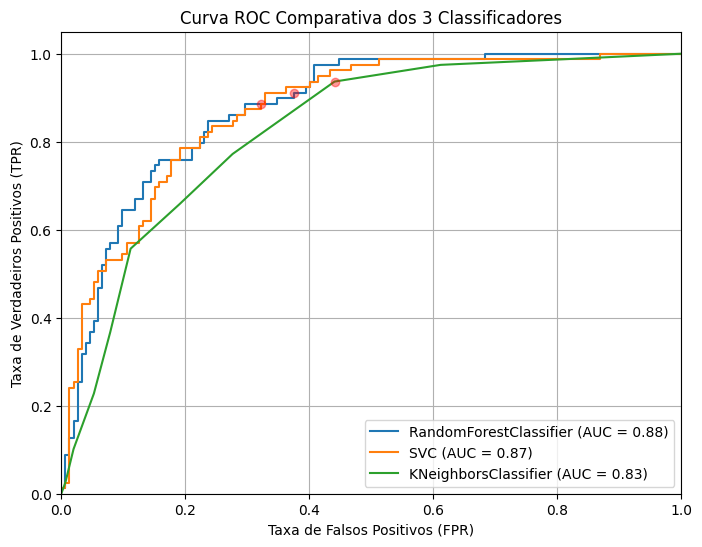

In [75]:
# Definir os classificadores, as probabilidades previstas e as matrizes de confusão
clfs = [random_forest_N, svm_N, knn_N]  
y_pred_probas = [avalM_RF_n[0], avalM_SVM_n[0], avalM_KNN_n[0]]  
conf_matrix = [avalM_RF_n[1], avalM_SVM_n[1], avalM_KNN_n[1]] 

# gerar a curva ROC
roc_curve_grafDraw(clfs, y_pred_probas, conf_matrix)

A curva ROC apresenta o desempenho dos três classificadores após a normalização dos dados. O RandomForestClassifier (linha azul) continua a destacar-se com uma AUC de 0.88, demonstrando a melhor capacidade discriminativa entre as três abordagens. O SVC (linha laranja) surge muito próximo, com AUC de 0.87, evidenciando um desempenho igualmente sólido e consistente.

O KNeighborsClassifier (linha verde), por sua vez, apresenta uma AUC de 0.83, situando-se abaixo dos outros dois modelos. Este resultado indica uma menor capacidade de separação entre as classes quando comparado com o Random Forest e o SVC, algo também visível pela sua curva menos inclinada e mais afastada do canto superior esquerdo do gráfico.

Apesar disso, as três curvas mostram comportamentos relativamente próximos, sugerindo que, após a normalização, todos os classificadores beneficiaram de um espaço de decisão mais uniforme. A transformação ajudou a estabilizar o desempenho global dos modelos, ainda que o Random Forest mantenha a liderança, seguido de perto pelo SVC, e com o KNN a apresentar um desempenho aceitável, embora inferior.

## Gráficos Comparativos dos 3 Classificadores Antes e Depois da Normalização

Para facilitar a comparação das métricas de desempenho dos modelos antes e depois da normalização dos dados, utilizou-se um gráfico de barras que apresenta a Accuracy, Precision, Recall e F-Score de cada classificador. Esta abordagem permite avaliar de forma mais clara o impacto da normalização nos resultados, identificando eventuais melhorias na capacidade dos classificadores em prever corretamente os casos positivos e negativos.

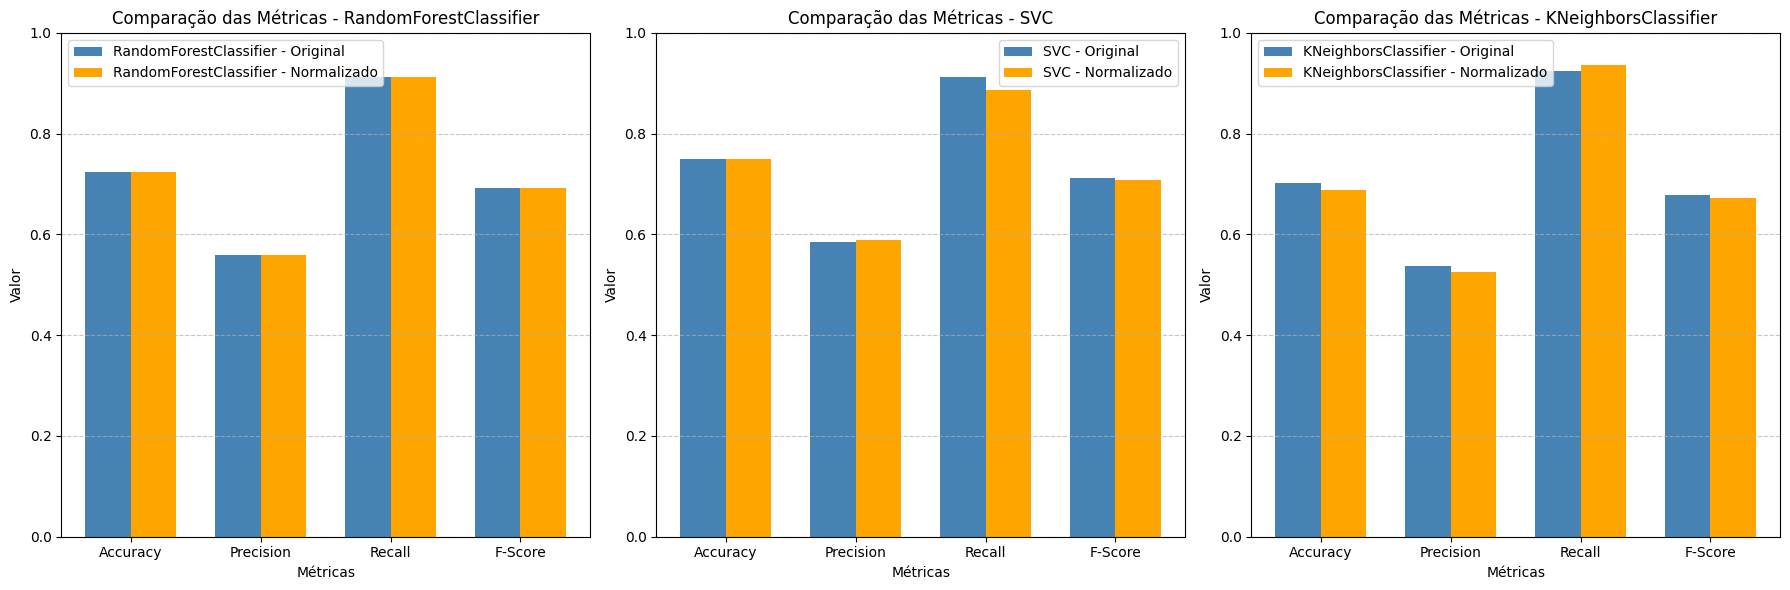

In [76]:
def drawComparGrafCombined(metrics_list, normalized_list):
    """
    Desenha todos os gráficos de comparação de métricas numa figura.
    
    metrics_list: lista de listas de métricas originais [[nome, acc, prec, rec, f1], ...]
    normalized_list: lista de listas de métricas normalizadas [[nome, acc, prec, rec, f1], ...]
    """
    metric_names = ['Accuracy', 'Precision', 'Recall', 'F-Score']
    x = np.arange(len(metric_names))
    width = 0.35
    num_graphs = len(metrics_list)
    
    # Criar figura com subplots
    fig, axes = plt.subplots(1, num_graphs, figsize=(6*num_graphs, 6))
    
    # Garantir que axes seja sempre um array mesmo com 1 gráfico
    if num_graphs == 1:
        axes = [axes]
    
    for ax, metrics, metrics_n in zip(axes, metrics_list, normalized_list):
        values = metrics[1:]
        values_n = metrics_n[1:]
        
        ax.bar(x - width/2, values, width, label=f"{metrics[0]} - Original", color='steelblue')
        ax.bar(x + width/2, values_n, width, label=f"{metrics_n[0]} - Normalizado", color='orange')
        
        ax.set_xlabel("Métricas")
        ax.set_ylabel("Valor")
        ax.set_title(f"Comparação das Métricas - {metrics[0]}")
        ax.set_xticks(x)
        ax.set_xticklabels(metric_names)
        ax.set_ylim(0, 1)
        ax.legend(loc="best")
        ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# Definir as métricas de cada modelo para comparar
metricsRF = avalM_RF[2]  # Métricas do Random Forest
metricsSVM = avalM_SVM[2]  # Métricas do SVM
metricsKNN = avalM_KNN[2]  # Métricas do KNN

# Métricas normalizadas de cada modelo
metricsRF_n = avalM_RF_n[2]  # Métricas normalizadas do Random Forest
metricsSVM_n = avalM_SVM_n[2]  # Métricas normalizadas do SVM
metricsKNN_n = avalM_KNN_n[2]  # Métricas normalizadas do KNN

# Listas de métricas originais e normalizadas
metrics_list = [metricsRF, metricsSVM, metricsKNN]
normalized_list = [metricsRF_n, metricsSVM_n, metricsKNN_n]

# Desenhar todos os gráficos em uma única figura
drawComparGrafCombined(metrics_list, normalized_list)


De maneira geral, observa-se que a normalização produziu pequenas variações de desempenho, sem alterar drasticamente o comportamento dos modelos. No RandomForestClassifier, a normalização manteve o recall praticamente inalterado, enquanto a precision sofreu uma ligeira redução. Ainda assim, o desempenho global permaneceu estável, indicando que o Random Forest não é particularmente sensível à escala dos dados.

No caso do SVM, a normalização resultou num comportamento mais equilibrado, mas com uma redução visível na precision e também no recall. Embora o desempenho continue elevado, os resultados indicam que o SVM foi moderadamente afetado pela transformação, tornando-se ligeiramente menos eficaz na distinção entre classes após a normalização.

Já no KNeighborsClassifier, a normalização teve um impacto mais evidente. A precision diminuiu, mas o recall sofreu um aumento significativo, aproximando-se de 1.0. Isso demonstra que o modelo se tornou muito mais sensível a casos positivos após a normalização — característica esperada, dado que o KNN depende diretamente das distâncias entre instâncias. O F-score manteve-se estável, refletindo um equilíbrio razoável entre precisão e recall.

Por fim, conclui-se que a normalização não modificou substancialmente os resultados do Random Forest, provocou uma ligeira queda de desempenho no SVM e trouxe uma mudança marcante no KNN, aumentando expressivamente o recall, ainda que à custa de precisão.